# Task 3: RAG Without Reranker

In [2]:
import sys
sys.path.insert(0, '..')
sys.path.insert(0, '.')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from openai import OpenAI
import time

from eval_utils import (
    load_questions, build_chunks, embed_chunks, run_generation_experiment,
    print_summary, summarize_results
)
from textwave.modules.extraction.embedding import Embedding
from textwave.modules.retrieval.index.bruteforce import BruteForceIndex

questions = load_questions(deduplicate=True)

# Use best chunking from Task 1 
BEST_STRATEGY = 'sentence'
BEST_PARAMS = dict(num_sentences=3, overlap_size=1)
K = 5

print('Building index...')
chunks, source_files = build_chunks(strategy=BEST_STRATEGY, **BEST_PARAMS)
embeddings = embed_chunks(chunks)
dim = embeddings.shape[1]
embedder = Embedding('all-MiniLM-L6-v2')

idx = BruteForceIndex(dim)
idx.add(embeddings, chunks)
print(f'Index built: {idx.ntotal} chunks!')

Building index...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5604.16it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6171.35it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Index built: 17161 chunks!


In [3]:
class QAGeneratorRAG:
    """Ollama generator with RAG context."""
    def __init__(self, model: str, temperature: float = 0.3):
        self.model = model
        self.client = OpenAI(api_key='ollama', base_url='http://localhost:11434/v1')
        self.temperature = temperature

    def generate_answer(self, query: str, context: list) -> str:
        combined = f"Question: {query}\n\nContext: {', '.join(context)}"
        response = self.client.chat.completions.create(
            model=self.model,
            temperature=self.temperature,
            max_tokens=120,
            messages=[
                {
                    'role': 'system',
                    'content': (
                        'You must answer the user questions only based on the provided context. '
                        'Do not use any external or prior knowledge. '
                        'Provide clear, concise, and full-sentence answers. '
                        'If the context does not mention the answer, respond with "No context".'
                    ),
                },
                {'role': 'user', 'content': combined},
            ],
        )
        time.sleep(1)
        return response.choices[0].message.content.strip()


def context_fn(query: str) -> list[str]:
    """Retrieve top-k chunks for a query."""
    query_vec = embedder.encode(query)
    return idx.search(query_vec, K)

print('Generator and context function ready!')

Generator and context function ready!


In [4]:
# Run RAG experiment for both models
rag_results = {}

for model_name in ['phi3:mini', 'qwen2.5:1.5b']:
    print(f'\nRunning RAG (no reranker) for {model_name}...')
    generator = QAGeneratorRAG(model=model_name)
    results = run_generation_experiment(
        questions_df=questions,
        generator=generator,
        context_fn=context_fn,
        sleep_sec=0,
    )
    results.to_csv(f'results_task3_{model_name.replace(":", "_")}.csv', index=False)
    rag_results[model_name] = results
    print_summary(f'{model_name} (RAG, no reranker)', results, 'transformer_match')

print('\nDone!')


Running RAG (no reranker) for phi3:mini...
Using device: cpu


Loading weights: 100%|██████████| 393/393 [00:00<00:00, 6067.60it/s]


Error on: (NNP Harding #)(NNP Death )))(PP (IN in )(NP (NP (NN office ... -> object of type 'float' has no len()
Error on: According to Reader's Digest, is Finland best for living?... -> RobertaTokenizer has no attribute encode_plus
Error on: Adams ' opponents were what?... -> RobertaTokenizer has no attribute encode_plus
Error on: Are Count Volta 's original instruments and papers on displa... -> object of type 'float' has no len()
Error on: Are Kangaroos Shy?... -> object of type 'float' has no len()
Error on: Are Native Ghanaian languages divided into two linguistic su... -> object of type 'float' has no len()
Error on: Are Sports in Indonesia generally male-orientated?... -> RobertaTokenizer has no attribute encode_plus
Error on: Are Various sporting events popular in Finland ?... -> object of type 'float' has no len()
Error on: Are Various trees claimed to be " the " apple tree which New... -> object of type 'float' has no len()
Error on: Are adult ducks fast fliers?... -> Roberta

Loading weights: 100%|██████████| 393/393 [00:00<00:00, 5561.07it/s]


Error on: (NNP Harding #)(NNP Death )))(PP (IN in )(NP (NP (NN office ... -> object of type 'float' has no len()
Error on: Adams ' opponents were what?... -> RobertaTokenizer has no attribute encode_plus
Error on: Are Count Volta 's original instruments and papers on displa... -> object of type 'float' has no len()
Error on: Are Kangaroos Shy?... -> object of type 'float' has no len()
Error on: Are Native Ghanaian languages divided into two linguistic su... -> object of type 'float' has no len()
Error on: Are Sports in Indonesia generally male-orientated?... -> RobertaTokenizer has no attribute encode_plus
Error on: Are Various sporting events popular in Finland ?... -> object of type 'float' has no len()
Error on: Are Various trees claimed to be " the " apple tree which New... -> object of type 'float' has no len()
Error on: Are a wolf's teeth its main weapons?... -> RobertaTokenizer has no attribute encode_plus
Error on: Are all official holidays in Finland established by acts of ...

In [5]:
# Load task 2 baselines for comparison
baseline_results = {}
for model_name in ['phi3:mini', 'qwen2.5:1.5b']:
    try:
        baseline_results[model_name] = pd.read_csv(f'results_task2_{model_name.replace(":", "_")}.csv')
    except:
        print(f'Warning: Task 2 results not found for {model_name}')

# Comparison table
rows = []
for model_name in ['phi3:mini', 'qwen2.5:1.5b']:
    for condition, df_dict in [('no RAG', baseline_results), ('RAG no reranker', rag_results)]:
        if model_name in df_dict:
            df = df_dict[model_name]
            rows.append({
                'Model': model_name,
                'Condition': condition,
                'Overall TM': df['transformer_match'].mean(),
                'Easy TM': df[df['difficulty']=='easy']['transformer_match'].mean(),
                'Medium TM': df[df['difficulty']=='medium']['transformer_match'].mean(),
                'Hard TM': df[df['difficulty']=='hard']['transformer_match'].mean(),
            })
comparison = pd.DataFrame(rows)
print('\nTable: Task 2 vs Task 3 Comparison')
print(comparison.to_string(index=False))


Table: Task 2 vs Task 3 Comparison
       Model       Condition  Overall TM  Easy TM  Medium TM  Hard TM
   phi3:mini          no RAG    0.282297 0.523364   0.241379 0.210526
   phi3:mini RAG no reranker    0.430622 0.663551   0.545977 0.336842
qwen2.5:1.5b          no RAG    0.293461 0.574766   0.206897 0.231579
qwen2.5:1.5b RAG no reranker    0.452951 0.724299   0.545977 0.326316


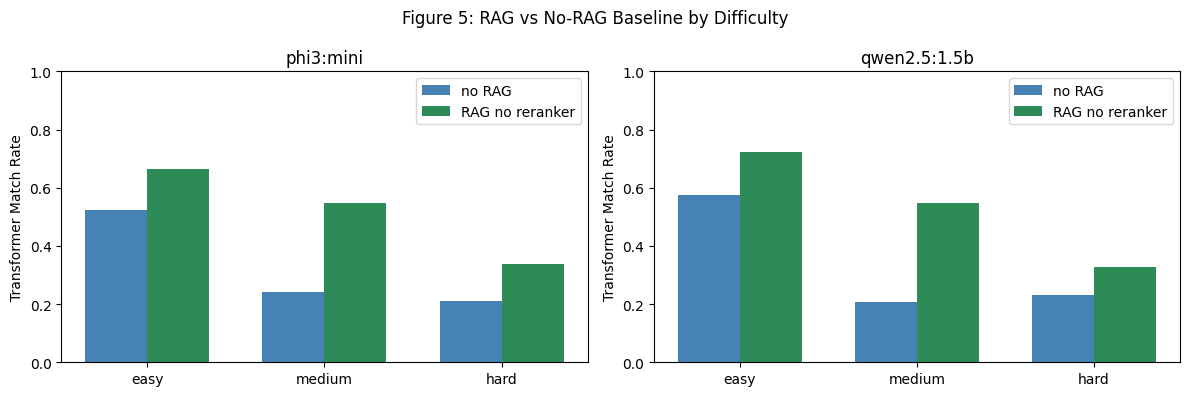

In [6]:
# Figure: RAG vs baseline comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
diffs = ['easy', 'medium', 'hard']
colors = {'no RAG': 'steelblue', 'RAG no reranker': 'seagreen'}

for ax, model_name in zip(axes, ['phi3:mini', 'qwen2.5:1.5b']):
    x = range(len(diffs))
    width = 0.35
    for i, (cond, df_dict) in enumerate([('no RAG', baseline_results), ('RAG no reranker', rag_results)]):
        if model_name in df_dict:
            df = df_dict[model_name]
            scores = [df[df['difficulty']==d]['transformer_match'].mean() for d in diffs]
            ax.bar([xi + i*width for xi in x], scores, width, label=cond, color=colors[cond])
    ax.set_title(model_name)
    ax.set_xticks([xi + width/2 for xi in x])
    ax.set_xticklabels(diffs)
    ax.set_ylabel('Transformer Match Rate')
    ax.set_ylim(0, 1)
    ax.legend()

plt.suptitle('Figure 5: RAG vs No-RAG Baseline by Difficulty')
plt.tight_layout()
plt.savefig('figures/task3_rag_vs_baseline.png', dpi=150)
plt.show()